# 06 — Financial Impact Validation

**Merchant Network Analytics — Model-Guided Acquisition Financial Impact**

Notebook ini menjawab lima pertanyaan bisnis:

1. Bagaimana acquiring Fee-Based Income (FBI) merchant direkonstruksi dari transaksi terobservasi?
2. Berapa Net FBI yang terkait dengan portfolio merchant acquiring BNI saat ini?
3. Berapa tambahan Potential Net FBI jika portfolio non-BNI berhasil diakuisisi sesuai rekomendasi model?
4. Berapa potensi uplift terhadap baseline acquiring FBI BNI saat ini?
5. Setelah product cost dan expected model error, berapa **Risk-Adjusted Expected Acquisition Value**?

> **Notebook ini adalah validation / audit notebook.** Notebook tidak melatih ulang graph maupun product recommendation model produksi, tidak mengubah artefak upstream, dan tidak mengklaim hasil sebagai pendapatan accounting resmi BNI.

Alur utama:

```text
Observed C2M Transactions → Gross MDR → Net FBI
  → Current BNI Acquiring FBI
  → Model-Guided Non-BNI Acquisition Potential
  → Product Cost → Potential Contribution
  → ML Precision → Expected TP/TN/FP/FN Economics
  → Risk-Adjusted Expected Acquisition Value
```


## 1 — Imports, Project Root, and Source Artifacts

Semua output finansial dibentuk dari artefak repository saat ini. `feature_table.csv` hanya digunakan untuk mereproduksi precision kelas QRIS yang tidak tersimpan langsung di metadata; proses ini adalah evaluasi in-memory, bukan perubahan atau refit artefak produksi.


In [1]:
import os
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ROOT = Path("." if os.path.isdir("./data") else "..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"


def format_rupiah(x):
    return f"Rp{x:,.0f}"


trx_clean = pd.read_csv(DATA_DIR / "transactions_clean.csv")
merchants_clean = pd.read_csv(DATA_DIR / "merchants_clean.csv")
mdr_saved = pd.read_csv(DATA_DIR / "merchant_mdr_profile.csv")
product_rec = pd.read_csv(DATA_DIR / "merchants_with_product_rec.csv")
feature_table = pd.read_csv(DATA_DIR / "feature_table.csv")
product_metadata = joblib.load(MODEL_DIR / "product_rec_metadata.pkl")

trx_clean["timestamp_dt"] = pd.to_datetime(trx_clean["timestamp_dt"])

artifact_summary = pd.DataFrame({
    "Artifact": [
        "transactions_clean.csv",
        "merchants_clean.csv",
        "merchant_mdr_profile.csv",
        "merchants_with_product_rec.csv",
        "feature_table.csv",
        "product_rec_metadata.pkl",
    ],
    "Purpose": [
        "Observed C2M transaction economics",
        "Merchant profile, skala_usaha, existing product",
        "Notebook 01 MDR/FBI artifact for reconciliation",
        "BNI status, priority context, product recommendation",
        "Labeled features for holdout precision reproduction",
        "Current product-model configuration and holdout metrics",
    ],
    "Rows / status": [
        f"{len(trx_clean):,} rows",
        f"{len(merchants_clean):,} rows",
        f"{len(mdr_saved):,} rows",
        f"{len(product_rec):,} rows",
        f"{len(feature_table):,} rows",
        f"loaded — {product_metadata.get('version', 'version unavailable')}",
    ],
})
display(artifact_summary)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Product model:", product_metadata.get("model_name"))


,Artifact,Purpose,Rows / status
0,transactions_clean.csv,Observed C2M transaction economics,"65,676 rows"
1,merchants_clean.csv,"Merchant profile, skala_usaha, existing product",708 rows
2,merchant_mdr_profile.csv,Notebook 01 MDR/FBI artifact for reconciliation,708 rows
3,merchants_with_product_rec.csv,"BNI status, priority context, product recommen...",708 rows
4,feature_table.csv,Labeled features for holdout precision reprodu...,708 rows
5,product_rec_metadata.pkl,Current product-model configuration and holdou...,loaded — pipeline_v2


PROJECT_ROOT: C:\Users\DELL\OneDrive\Desktop\odp_python\capstone_merchant
Product model: Logistic Regression


## 2 — Economic Assumptions

Distingsi metodologis yang dipakai konsisten di seluruh notebook:

- **Gross MDR** = jumlah `transaction amount × applicable MDR rate` sebelum retained-share assumption.
- **Net Fee-Based Income (Net FBI)** = `Gross MDR × 85%`, sebelum product operating cost.
- **Contribution** = `Net FBI − Product Cost`.
- **Risk-Adjusted Expected Acquisition Value** = correct-recommendation contribution dikurangi FP incremental EDC cost dan FN opportunity loss.

Semua rate dan cost di bawah adalah **capstone economic assumptions**, bukan klaim angka resmi internal BNI. QRIS + EDC cost adalah Rp50.000 + Rp200.000 = Rp250.000 per merchant per bulan.


In [2]:
NET_FBI_SHARE = 0.85

MDR_QRIS_UMI_HIGH = 0.003
MDR_QRIS_REGULAR = 0.007
MDR_EDC_DEBIT = 0.0015
MDR_EDC_CREDIT = 0.02

QRIS_COST = 50_000
EDC_COST = 200_000

assumptions = pd.DataFrame({
    "Capstone economic assumption": [
        "Net FBI retained share", "QRIS UMI > Rp500k MDR",
        "QRIS non-UMI MDR", "EDC debit MDR", "EDC credit-card MDR",
        "QRIS monthly cost", "Incremental EDC monthly cost",
        "QRIS + EDC monthly cost",
    ],
    "Value": [
        "85%", "0.30%", "0.70%", "0.15%", "2.00%",
        format_rupiah(QRIS_COST), format_rupiah(EDC_COST),
        format_rupiah(QRIS_COST + EDC_COST),
    ],
})
display(assumptions)


,Capstone economic assumption,Value
0,Net FBI retained share,85%
1,QRIS UMI > Rp500k MDR,0.30%
2,QRIS non-UMI MDR,0.70%
3,EDC debit MDR,0.15%
4,EDC credit-card MDR,2.00%
5,QRIS monthly cost,"Rp50,000"
6,Incremental EDC monthly cost,"Rp200,000"
7,QRIS + EDC monthly cost,"Rp250,000"


## 3 — Reconstruct Merchant MDR / FBI Directly from Transactions

Hanya transaksi `trx_type == "C2M"` yang digunakan. Rate QRIS ditentukan oleh `skala_usaha` dan threshold Rp500.000; rate EDC ditentukan oleh `payment_type`. Payment type lain memiliki MDR nol dalam scope ini. Gross MDR dihitung per transaksi, kemudian diagregasi per merchant dan dinormalisasi dengan observation period yang ditentukan dinamis.


In [3]:
trx_econ = trx_clean.loc[trx_clean["trx_type"].eq("C2M")].copy()
trx_econ = trx_econ.merge(
    merchants_clean[["merchant_id", "skala_usaha"]],
    left_on="target_id",
    right_on="merchant_id",
    how="left",
    validate="many_to_one",
)
assert trx_econ["skala_usaha"].notna().all(), "Ada transaksi C2M tanpa skala_usaha merchant."

trx_econ["qris_rate"] = np.where(
    trx_econ["payment_type"].eq("QRIS"),
    np.where(
        trx_econ["skala_usaha"].eq("UMI"),
        np.where(trx_econ["amount"].le(500_000), 0.0, MDR_QRIS_UMI_HIGH),
        MDR_QRIS_REGULAR,
    ),
    0.0,
)
trx_econ["edc_rate"] = np.select(
    [
        trx_econ["payment_type"].eq("debit"),
        trx_econ["payment_type"].eq("credit_card"),
    ],
    [MDR_EDC_DEBIT, MDR_EDC_CREDIT],
    default=0.0,
)

trx_econ["gross_qris_mdr"] = trx_econ["amount"] * trx_econ["qris_rate"]
trx_econ["gross_edc_mdr"] = trx_econ["amount"] * trx_econ["edc_rate"]
trx_econ["qris_amount"] = np.where(
    trx_econ["payment_type"].eq("QRIS"), trx_econ["amount"], 0.0
)
trx_econ["edc_amount"] = np.where(
    trx_econ["payment_type"].isin(["debit", "credit_card"]),
    trx_econ["amount"],
    0.0,
)

period_start = trx_econ["timestamp_dt"].min().to_period("M")
period_end = trx_econ["timestamp_dt"].max().to_period("M")
OBSERVATION_MONTHS = (
    (period_end.year - period_start.year) * 12
    + period_end.month - period_start.month + 1
)

merchant_agg = (
    trx_econ.groupby("target_id", as_index=False)
    .agg(
        observed_qris_amount=("qris_amount", "sum"),
        observed_edc_amount=("edc_amount", "sum"),
        gross_qris_mdr_period=("gross_qris_mdr", "sum"),
        gross_edc_mdr_period=("gross_edc_mdr", "sum"),
    )
    .rename(columns={"target_id": "merchant_id"})
)
mdr_rebuilt = merchants_clean[["merchant_id"]].merge(
    merchant_agg, on="merchant_id", how="left", validate="one_to_one"
)
rebuilt_amount_cols = [c for c in mdr_rebuilt.columns if c != "merchant_id"]
mdr_rebuilt[rebuilt_amount_cols] = mdr_rebuilt[rebuilt_amount_cols].fillna(0.0)
mdr_rebuilt["observation_months"] = OBSERVATION_MONTHS
mdr_rebuilt["monthly_gross_qris_mdr"] = (
    mdr_rebuilt["gross_qris_mdr_period"] / OBSERVATION_MONTHS
)
mdr_rebuilt["monthly_gross_edc_mdr"] = (
    mdr_rebuilt["gross_edc_mdr_period"] / OBSERVATION_MONTHS
)
mdr_rebuilt["monthly_net_qris_fbi"] = (
    mdr_rebuilt["monthly_gross_qris_mdr"] * NET_FBI_SHARE
)
mdr_rebuilt["monthly_net_edc_fbi"] = (
    mdr_rebuilt["monthly_gross_edc_mdr"] * NET_FBI_SHARE
)
mdr_rebuilt["monthly_net_total_fbi"] = (
    mdr_rebuilt["monthly_net_qris_fbi"] + mdr_rebuilt["monthly_net_edc_fbi"]
)

observation_summary = pd.DataFrame({
    "Metric": ["Observation window", "Observation months", "C2M rows used", "Merchant count"],
    "Value": [
        f"{period_start} to {period_end}", OBSERVATION_MONTHS,
        f"{len(trx_econ):,}", f"{len(mdr_rebuilt):,}",
    ],
})
display(observation_summary)
display(mdr_rebuilt[[
    "monthly_gross_qris_mdr", "monthly_gross_edc_mdr",
    "monthly_net_qris_fbi", "monthly_net_edc_fbi", "monthly_net_total_fbi",
]].describe().T)


,Metric,Value
0,Observation window,2025-07 to 2026-06
1,Observation months,12
2,C2M rows used,"49,066"
3,Merchant count,708


,count,mean,std,min,25%,50%,75%,max
monthly_gross_qris_mdr,708.0000,"142,821.9138","126,789.4934",0.0000,"1,524.9656","163,699.1268","238,508.0113","625,027.2921"
monthly_gross_edc_mdr,708.0000,"288,463.5957","399,242.7291",54.2234,"4,527.7627","178,939.3254","387,041.4147","3,059,161.3020"
monthly_net_qris_fbi,708.0000,"121,398.6267","107,771.0694",0.0000,"1,296.2208","139,144.2578","202,731.8096","531,273.1983"
monthly_net_edc_fbi,708.0000,"245,194.0564","339,356.3197",46.0899,"3,848.5983","152,098.4266","328,985.2025","2,600,287.1067"
monthly_net_total_fbi,708.0000,"366,592.6831","420,311.4282",688.4777,"5,180.3282","307,291.9237","540,035.6881","3,088,729.2488"


## 4 — Reconcile Reconstructed FBI with Notebook 01 Artifact

Reconciliation merchant-level ini membuktikan bahwa financial building blocks berikut berasal dari transaksi dan MDR rules, bukan input manual. Perbedaan maksimum diharapkan mendekati nol dalam floating-point tolerance.


In [4]:
reconcile_cols = [
    "monthly_gross_qris_mdr", "monthly_gross_edc_mdr",
    "monthly_net_qris_fbi", "monthly_net_edc_fbi", "monthly_net_total_fbi",
]
mdr_check = mdr_saved[["merchant_id"] + reconcile_cols].merge(
    mdr_rebuilt[["merchant_id"] + reconcile_cols],
    on="merchant_id", how="outer", suffixes=("_saved", "_rebuilt"),
    validate="one_to_one",
)
reconciliation_rows = []
for col in reconcile_cols:
    saved = mdr_check[f"{col}_saved"]
    rebuilt = mdr_check[f"{col}_rebuilt"]
    max_diff = (saved - rebuilt).abs().max()
    reconciliation_rows.append({
        "Variable": col,
        "Max absolute difference": max_diff,
        "Status": "PASS" if np.allclose(
            saved, rebuilt, rtol=1e-9, atol=1e-6, equal_nan=True
        ) else "CHECK",
    })
mdr_validation = pd.DataFrame(reconciliation_rows)
display(mdr_validation)
assert mdr_validation["Status"].eq("PASS").all()
print("PASS — Merchant MDR/FBI profile reproduced from transaction data.")


,Variable,Max absolute difference,Status
0,monthly_gross_qris_mdr,0.0000,PASS
1,monthly_gross_edc_mdr,0.0000,PASS
2,monthly_net_qris_fbi,0.0000,PASS
3,monthly_net_edc_fbi,0.0000,PASS
4,monthly_net_total_fbi,0.0000,PASS


PASS — Merchant MDR/FBI profile reproduced from transaction data.


## 5 — Build the Financial Analysis Table

`merchants_with_product_rec.csv` adalah sumber status BNI, acquisition-priority context, dan rekomendasi produk. Kolom kanonis produk existing pada repository saat ini adalah `produk_bni`; notebook menyalinnya ke alias transparan `current_bni_product` tanpa membuat atau menginferensikan klasifikasi baru. Priority tidak digunakan sebagai input formula finansial.


In [5]:
assert product_rec["merchant_id"].is_unique
assert merchants_clean["merchant_id"].is_unique
assert mdr_saved["merchant_id"].is_unique
assert mdr_rebuilt["merchant_id"].is_unique

analysis = product_rec.merge(
    mdr_rebuilt, on="merchant_id", how="left", validate="one_to_one"
)
analysis["current_bni_product"] = analysis["produk_bni"]

required_analysis_cols = [
    "merchant_id", "nama", "is_bni_acquiring", "current_bni_product",
    "product_recommendation", "product_rec_proba_edc",
    "monthly_net_qris_fbi", "monthly_net_edc_fbi",
    "priority_score", "priority_category",
]
assert analysis[required_analysis_cols].shape[0] == product_rec.shape[0]

existing_bni = analysis.loc[analysis["is_bni_acquiring"].eq("Ya")].copy()
target = analysis.loc[analysis["is_bni_acquiring"].eq("Tidak")].copy()
display(pd.DataFrame({
    "Portfolio": ["Existing BNI acquiring", "Non-BNI acquisition targets"],
    "Merchant count": [len(existing_bni), len(target)],
}))


,Portfolio,Merchant count
0,Existing BNI acquiring,462
1,Non-BNI acquisition targets,246


## 6 — Current BNI Acquiring Net FBI — “Before”

Baseline memakai **produk BNI existing yang terobservasi**, bukan prediksi model:

- Current product `QRIS` → `monthly_net_qris_fbi`
- Current product `QRIS + EDC` → `monthly_net_qris_fbi + monthly_net_edc_fbi`

Hasilnya adalah estimasi baseline acquiring FBI untuk portfolio merchant dalam dataset capstone, bukan official BNI accounting income.


In [6]:
valid_products = {"QRIS", "QRIS + EDC"}
unexpected_existing_products = set(existing_bni["current_bni_product"].dropna()) - valid_products
assert not unexpected_existing_products, (
    f"Unexpected existing BNI products: {unexpected_existing_products}"
)
assert existing_bni["current_bni_product"].notna().all()

existing_bni["current_bni_net_fbi"] = np.select(
    [
        existing_bni["current_bni_product"].eq("QRIS"),
        existing_bni["current_bni_product"].eq("QRIS + EDC"),
    ],
    [
        existing_bni["monthly_net_qris_fbi"],
        existing_bni["monthly_net_qris_fbi"] + existing_bni["monthly_net_edc_fbi"],
    ],
    default=np.nan,
)
assert existing_bni["current_bni_net_fbi"].notna().all()
current_bni_acquiring_fbi = float(existing_bni["current_bni_net_fbi"].sum())

current_baseline = pd.DataFrame({
    "Metric": [
        "Existing BNI acquiring merchants", "Current product QRIS count",
        "Current product QRIS + EDC count", "Current BNI Acquiring Net FBI / month",
    ],
    "Value": [
        f"{len(existing_bni):,}",
        f"{existing_bni['current_bni_product'].eq('QRIS').sum():,}",
        f"{existing_bni['current_bni_product'].eq('QRIS + EDC').sum():,}",
        format_rupiah(current_bni_acquiring_fbi),
    ],
})
display(current_baseline)


,Metric,Value
0,Existing BNI acquiring merchants,462
1,Current product QRIS count,213
2,Current product QRIS + EDC count,249
3,Current BNI Acquiring Net FBI / month,"Rp138,769,736"


## 7 — Non-BNI Model-Guided Acquisition Portfolio

```text
Graph / acquisition priority → menentukan WHO (contextual)
Product recommendation model → menentukan WHAT (QRIS atau QRIS + EDC)
Financial impact notebook    → menghitung HOW MUCH
```

Jumlah di bawah selalu dibaca dari artefak rekomendasi terbaru dan tidak di-hardcode.


In [7]:
recommendation_counts = (
    target["product_recommendation"]
    .value_counts()
    .reindex(["QRIS", "QRIS + EDC"], fill_value=0)
)
n_target = len(target)
n_qris = int(recommendation_counts["QRIS"])
n_edc = int(recommendation_counts["QRIS + EDC"])

display(pd.DataFrame({
    "Portfolio output": ["Total non-BNI targets", "Predicted QRIS", "Predicted QRIS + EDC"],
    "Merchant count": [n_target, n_qris, n_edc],
}))
assert n_qris + n_edc == n_target


,Portfolio output,Merchant count
0,Total non-BNI targets,246
1,Predicted QRIS,98
2,Predicted QRIS + EDC,148


## 8 — Potential Net FBI After Model-Guided Acquisition

Product recommendation model **tidak memprediksi uang secara langsung**. Model memprediksi `QRIS` atau `QRIS + EDC`; rekomendasi tersebut menentukan komponen FBI berbasis transaksi yang relevan:

- Recommended `QRIS` → Net FBI QRIS
- Recommended `QRIS + EDC` → Net FBI QRIS + Net FBI EDC

Untuk merchant non-BNI, nilai ini bukan current BNI income. Nilai ini adalah potential acquiring Net FBI jika merchant berhasil diakuisisi oleh BNI dan menggunakan produk yang direkomendasikan model.


In [8]:
target["potential_net_fbi_after_acquisition"] = np.where(
    target["product_recommendation"].eq("QRIS + EDC"),
    target["monthly_net_qris_fbi"] + target["monthly_net_edc_fbi"],
    target["monthly_net_qris_fbi"],
)
potential_net_fbi_non_bni = float(target["potential_net_fbi_after_acquisition"].sum())

potential_by_product = (
    target.groupby("product_recommendation")["potential_net_fbi_after_acquisition"]
    .agg([("Merchant count", "size"), ("Potential Net FBI / month", "sum"),
          ("Average / merchant", "mean")])
    .reindex(["QRIS", "QRIS + EDC"])
    .reset_index()
)
potential_by_product["Potential Net FBI / month"] = potential_by_product[
    "Potential Net FBI / month"
].map(format_rupiah)
potential_by_product["Average / merchant"] = potential_by_product[
    "Average / merchant"
].map(format_rupiah)
display(potential_by_product)
print("Total Potential Net FBI — non-BNI target portfolio:",
      format_rupiah(potential_net_fbi_non_bni), "/ month")


,product_recommendation,Merchant count,Potential Net FBI / month,Average / merchant
0,QRIS,98,"Rp6,889,943","Rp70,306"
1,QRIS + EDC,148,"Rp94,229,721","Rp636,687"


Total Potential Net FBI — non-BNI target portfolio: Rp101,119,664 / month


## 9 — Before vs After Acquisition: Non-BNI Target View

Sebelum akuisisi, BNI Acquiring FBI dari target non-BNI adalah **Rp0 per bulan**. Observed C2M transactions mereka hanya digunakan untuk mengestimasi economics jika akuisisi berhasil.

> **Percentage growth tidak dihitung untuk non-BNI-only view karena baseline-nya nol.** Pertumbuhan dari Rp0 tidak terdefinisi; notebook hanya menampilkan absolute incremental potential.


In [9]:
non_bni_before_after = pd.DataFrame({
    "Scenario": [
        "Before acquisition — target non-BNI",
        "After successful model-guided acquisition",
        "Absolute incremental potential",
    ],
    "Net FBI / month": [
        format_rupiah(0),
        format_rupiah(potential_net_fbi_non_bni),
        format_rupiah(potential_net_fbi_non_bni),
    ],
})
display(non_bni_before_after)


,Scenario,Net FBI / month
0,Before acquisition — target non-BNI,Rp0
1,After successful model-guided acquisition,"Rp101,119,664"
2,Absolute incremental potential,"Rp101,119,664"


## 10 — Current BNI FBI vs Post-Acquisition Potential FBI

Persentase uplift valid pada total portfolio karena baseline current BNI acquiring FBI lebih besar dari nol.

```text
Potential FBI Uplift %
= Potential Net FBI from Non-BNI Targets
  ÷ Current BNI Acquiring Net FBI
  × 100%
```

Angka ini adalah **Estimated Potential Increase in BNI Acquiring Net FBI**, bukan realized growth, actual revenue growth, atau official BNI FBI growth.


In [10]:
post_acquisition_potential_fbi = (
    current_bni_acquiring_fbi + potential_net_fbi_non_bni
)
absolute_fbi_uplift = post_acquisition_potential_fbi - current_bni_acquiring_fbi
fbi_uplift_pct = (
    absolute_fbi_uplift / current_bni_acquiring_fbi * 100
    if current_bni_acquiring_fbi > 0 else np.nan
)

portfolio_uplift = pd.DataFrame({
    "Metric": [
        "Current BNI Acquiring Net FBI / month",
        "Potential Net FBI from Non-BNI Acquisition",
        "Post-Acquisition Potential BNI Acquiring FBI",
        "Absolute FBI Uplift",
        "Potential FBI Uplift",
    ],
    "Value": [
        format_rupiah(current_bni_acquiring_fbi),
        format_rupiah(potential_net_fbi_non_bni),
        format_rupiah(post_acquisition_potential_fbi),
        format_rupiah(absolute_fbi_uplift),
        f"{fbi_uplift_pct:.2f}%",
    ],
})
display(portfolio_uplift)


,Metric,Value
0,Current BNI Acquiring Net FBI / month,"Rp138,769,736"
1,Potential Net FBI from Non-BNI Acquisition,"Rp101,119,664"
2,Post-Acquisition Potential BNI Acquiring FBI,"Rp239,889,400"
3,Absolute FBI Uplift,"Rp101,119,664"
4,Potential FBI Uplift,72.87%


## 11 — Visualize BNI Acquiring FBI Before vs Potential After

Visual berikut memisahkan total-portfolio uplift (persentase valid) dari non-BNI-only scenario (baseline nol, tanpa persentase).


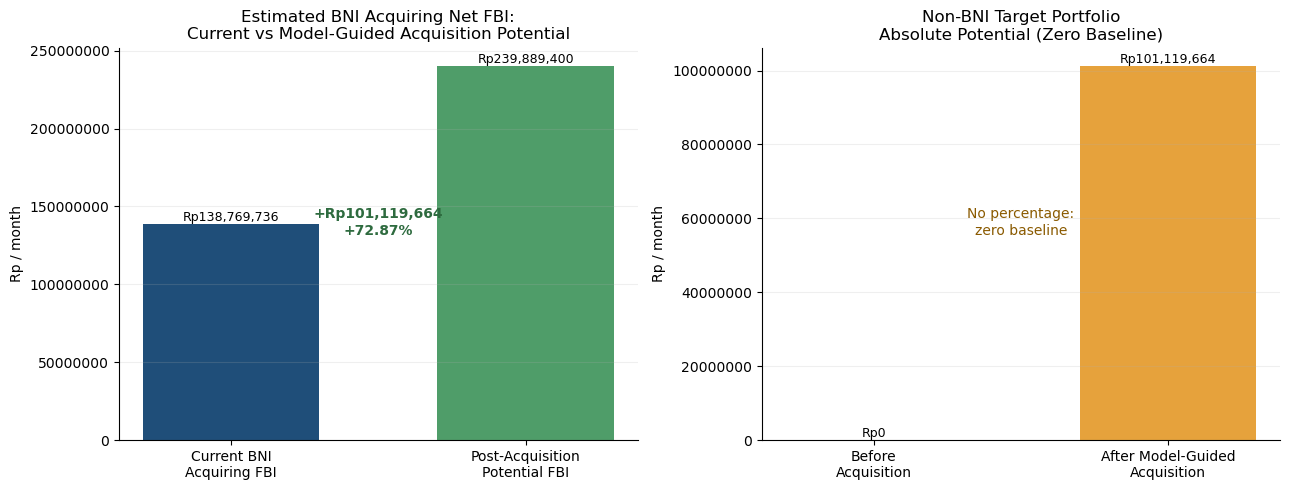

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

total_values = [current_bni_acquiring_fbi, post_acquisition_potential_fbi]
bars = axes[0].bar(
    ["Current BNI\nAcquiring FBI", "Post-Acquisition\nPotential FBI"],
    total_values, color=["#1f4e79", "#4f9d69"], width=0.6,
)
axes[0].set_title("Estimated BNI Acquiring Net FBI:\nCurrent vs Model-Guided Acquisition Potential")
axes[0].set_ylabel("Rp / month")
axes[0].ticklabel_format(style="plain", axis="y")
for bar, value in zip(bars, total_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, value, format_rupiah(value),
                 ha="center", va="bottom", fontsize=9)
axes[0].text(0.5, max(total_values) * 0.55,
             f"+{format_rupiah(absolute_fbi_uplift)}\n+{fbi_uplift_pct:.2f}%",
             ha="center", color="#2e6b3f", fontweight="bold")

target_values = [0, potential_net_fbi_non_bni]
bars_target = axes[1].bar(
    ["Before\nAcquisition", "After Model-Guided\nAcquisition"],
    target_values, color=["#a7a9ac", "#e6a23c"], width=0.6,
)
axes[1].set_title("Non-BNI Target Portfolio\nAbsolute Potential (Zero Baseline)")
axes[1].set_ylabel("Rp / month")
axes[1].ticklabel_format(style="plain", axis="y")
for bar, value in zip(bars_target, target_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, value, format_rupiah(value),
                 ha="center", va="bottom", fontsize=9)
axes[1].text(0.5, max(target_values) * 0.55,
             "No percentage:\nzero baseline", ha="center", color="#8a5a00")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## 12 — Product Cost and Potential Contribution

Cost baru diterapkan setelah revenue-potential layer ditampilkan:

- Predicted QRIS → Rp50.000 per merchant per bulan
- Predicted QRIS + EDC → Rp250.000 per merchant per bulan

`Potential Contribution Before Model Risk = Potential Net FBI − Product Cost`.


In [12]:
target["product_cost"] = np.where(
    target["product_recommendation"].eq("QRIS + EDC"),
    QRIS_COST + EDC_COST,
    QRIS_COST,
)
target["potential_contribution"] = (
    target["potential_net_fbi_after_acquisition"] - target["product_cost"]
)

total_product_cost = float(target["product_cost"].sum())
potential_contribution_before_model_risk = float(target["potential_contribution"].sum())
contribution_bridge = pd.DataFrame({
    "Layer": ["Potential Net FBI", "Less: Total Product Cost",
              "Potential Contribution Before ML Error Adjustment"],
    "Value / month": [
        format_rupiah(potential_net_fbi_non_bni),
        f"−{format_rupiah(total_product_cost)}",
        format_rupiah(potential_contribution_before_model_risk),
    ],
})
display(contribution_bridge)


,Layer,Value / month
0,Potential Net FBI,"Rp101,119,664"
1,Less: Total Product Cost,"−Rp41,900,000"
2,Potential Contribution Before ML Error Adjustment,"Rp59,219,664"


## 13 — Product Model Metrics as the Bridge to Risk Adjustment

Perhitungan finansial dimulai dari kelompok yang diproduksi model: predicted QRIS dan predicted QRIS + EDC. Karena itu, **precision** mengestimasi expected share rekomendasi yang benar di dalam masing-masing predicted group.

Metadata menyimpan precision kelas EDC, Macro-F1, dan ROC-AUC. Precision kelas QRIS direproduksi secara in-memory memakai holdout split, konfigurasi, feature set, dan parameter final yang tersimpan. Ini tidak melakukan tuning ulang dan tidak mengubah model produksi. Accuracy ditampilkan untuk audit, tetapi **tidak digunakan sebagai direct FBI discount**.


In [13]:
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20


def assign_product_label(product):
    if pd.isna(product):
        return np.nan
    product_upper = str(product).upper()
    if "EDC" in product_upper:
        return 1
    if "QRIS" in product_upper:
        return 0
    return np.nan


product_features = list(product_metadata["feature_columns"])
categorical_features = [c for c in ["kategori", "kota"] if c in product_features]
numeric_features = [c for c in product_features if c not in categorical_features]
numeric_indices = list(range(len(numeric_features)))
categorical_indices = list(range(len(numeric_features), len(product_features)))

labeled = feature_table.loc[feature_table["is_bni_acquiring"].eq("Ya")].copy()
labeled["product_label"] = labeled["produk_bni"].apply(assign_product_label)
labeled = labeled.dropna(subset=["product_label"]).copy()
labeled["product_label"] = labeled["product_label"].astype(int)
X = labeled[product_features]
y = labeled["product_label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)


def onehot_preprocessor():
    numeric = SklearnPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical = SklearnPipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("numeric", numeric, numeric_features),
        ("categorical", categorical, categorical_features),
    ], sparse_threshold=0, verbose_feature_names_out=False)


def smotenc_preprocessor():
    numeric = SklearnPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical = SklearnPipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    return ColumnTransformer([
        ("numeric", numeric, numeric_features),
        ("categorical", categorical, categorical_features),
    ], sparse_threshold=0, verbose_feature_names_out=False)


def smotenc_postprocessor():
    return ColumnTransformer([
        ("numeric", "passthrough", numeric_indices),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         categorical_indices),
    ], sparse_threshold=0, verbose_feature_names_out=False)


def build_model(model_name):
    if model_name == "Logistic Regression":
        return LogisticRegression(max_iter=3_000, solver="liblinear", random_state=RANDOM_STATE)
    if model_name == "Random Forest":
        return RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)
    if model_name == "XGBoost":
        from xgboost import XGBClassifier
        return XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1)
    raise ValueError(f"Unsupported model for validation: {model_name}")


def evaluation_pipeline(model, balancing_strategy):
    if balancing_strategy == "SMOTENC":
        return Pipeline([
            ("preprocess", smotenc_preprocessor()),
            ("balance", SMOTENC(categorical_features=categorical_indices,
                                random_state=RANDOM_STATE, k_neighbors=5)),
            ("postprocess", smotenc_postprocessor()),
            ("model", model),
        ])
    sampler = (SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
               if balancing_strategy == "SMOTE" else "passthrough")
    return Pipeline([
        ("preprocess", onehot_preprocessor()),
        ("balance", sampler),
        ("model", model),
    ])


holdout_pipeline = evaluation_pipeline(
    build_model(product_metadata["model_name"]),
    product_metadata["balancing_strategy"],
)
holdout_pipeline.set_params(**dict(product_metadata["best_params"]))
holdout_pipeline.fit(X_train, y_train)
y_pred = holdout_pipeline.predict(X_test)
y_proba = holdout_pipeline.predict_proba(X_test)[:, 1]

precision_qris_for_risk = float(
    precision_score(y_test, y_pred, pos_label=0, zero_division=0)
)
precision_edc_rebuilt = float(
    precision_score(y_test, y_pred, pos_label=1, zero_division=0)
)
metadata_metrics = product_metadata["test_metrics"]
precision_edc_for_risk = float(metadata_metrics["precision_edc"])
assert np.isclose(precision_edc_rebuilt, precision_edc_for_risk)

model_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy", "Balanced Accuracy", "Precision QRIS",
        "Precision QRIS + EDC", "Macro-F1", "ROC-AUC",
    ],
    "Value": [
        metadata_metrics["accuracy"], metadata_metrics["balanced_accuracy"],
        precision_qris_for_risk, precision_edc_for_risk,
        metadata_metrics["macro_f1"], metadata_metrics["roc_auc"],
    ],
    "Source": [
        "product_rec_metadata.pkl", "product_rec_metadata.pkl",
        "Reproduced current holdout", "product_rec_metadata.pkl + reproduction check",
        "product_rec_metadata.pkl", "product_rec_metadata.pkl",
    ],
})
model_metrics["Display"] = model_metrics["Value"].map(lambda x: f"{x:.2%}")
display(model_metrics[["Metric", "Display", "Source"]])


,Metric,Display,Source
0,Accuracy,76.34%,product_rec_metadata.pkl
1,Balanced Accuracy,76.86%,product_rec_metadata.pkl
2,Precision QRIS,70.59%,Reproduced current holdout
3,Precision QRIS + EDC,83.33%,product_rec_metadata.pkl + reproduction check
4,Macro-F1,76.34%,product_rec_metadata.pkl
5,ROC-AUC,83.72%,product_rec_metadata.pkl


## 14 — Expected TP / TN / FP / FN from Current Model Output

Precision diterapkan pada **jumlah hasil rekomendasi**, bukan pada FBI total:

- Expected TP = Predicted QRIS + EDC × Precision QRIS + EDC
- Expected FP = Predicted QRIS + EDC × (1 − Precision QRIS + EDC)
- Expected TN = Predicted QRIS × Precision QRIS
- Expected FN = Predicted QRIS × (1 − Precision QRIS)

Expected count boleh desimal karena merupakan portfolio expected values, bukan actual label merchant non-BNI individual.


In [14]:
expected_tp = n_edc * precision_edc_for_risk
expected_fp = n_edc * (1 - precision_edc_for_risk)
expected_tn = n_qris * precision_qris_for_risk
expected_fn = n_qris * (1 - precision_qris_for_risk)

expected_confusion = pd.DataFrame({
    "Expected outcome": ["TP", "TN", "FP", "FN"],
    "Formula": [
        f"{n_edc} × {precision_edc_for_risk:.2%}",
        f"{n_qris} × {precision_qris_for_risk:.2%}",
        f"{n_edc} × (1 − {precision_edc_for_risk:.2%})",
        f"{n_qris} × (1 − {precision_qris_for_risk:.2%})",
    ],
    "Expected merchants": [expected_tp, expected_tn, expected_fp, expected_fn],
})
display(expected_confusion)


,Expected outcome,Formula,Expected merchants
0,TP,148 × 83.33%,123.3333
1,TN,98 × 70.59%,69.1765
2,FP,148 × (1 − 83.33%),24.6667
3,FN,98 × (1 − 70.59%),28.8235


## 15 — Contribution by Recommendation Group

Tabel ini mempertahankan traceability dari FBI ke cost lalu contribution untuk masing-masing predicted group. Semua nilai dihitung dari current artifact; tidak ada average contribution lama yang di-hardcode.


In [15]:
edc_rec = target.loc[target["product_recommendation"].eq("QRIS + EDC")].copy()
qris_rec = target.loc[target["product_recommendation"].eq("QRIS")].copy()

contribution_by_group = pd.DataFrame([
    {
        "Recommendation": "QRIS + EDC",
        "Merchants": len(edc_rec),
        "Net FBI QRIS": edc_rec["monthly_net_qris_fbi"].sum(),
        "Net FBI EDC": edc_rec["monthly_net_edc_fbi"].sum(),
        "Total Net FBI": edc_rec["potential_net_fbi_after_acquisition"].sum(),
        "Product Cost": edc_rec["product_cost"].sum(),
        "Contribution": edc_rec["potential_contribution"].sum(),
        "Average Contribution / merchant": edc_rec["potential_contribution"].mean(),
    },
    {
        "Recommendation": "QRIS",
        "Merchants": len(qris_rec),
        "Net FBI QRIS": qris_rec["monthly_net_qris_fbi"].sum(),
        "Net FBI EDC": 0.0,
        "Total Net FBI": qris_rec["potential_net_fbi_after_acquisition"].sum(),
        "Product Cost": qris_rec["product_cost"].sum(),
        "Contribution": qris_rec["potential_contribution"].sum(),
        "Average Contribution / merchant": qris_rec["potential_contribution"].mean(),
    },
])
contribution_display = contribution_by_group.copy()
money_cols = [
    "Net FBI QRIS", "Net FBI EDC", "Total Net FBI", "Product Cost",
    "Contribution", "Average Contribution / merchant",
]
for col in money_cols:
    contribution_display[col] = contribution_display[col].map(format_rupiah)
display(contribution_display)


,Recommendation,Merchants,Net FBI QRIS,Net FBI EDC,Total Net FBI,Product Cost,Contribution,Average Contribution / merchant
0,QRIS + EDC,148,"Rp29,627,380","Rp64,602,341","Rp94,229,721","Rp37,000,000","Rp57,229,721","Rp386,687"
1,QRIS,98,"Rp6,889,943",Rp0,"Rp6,889,943","Rp4,900,000","Rp1,989,943","Rp20,306"


## 16 — False Positive Economic Risk

FP berarti `QRIS + EDC` direkomendasikan padahal QRIS sudah cukup. Karena QRIS adalah base product pada kedua kelas, FP penalty hanya **incremental EDC cost = Rp200.000 per merchant per bulan**, bukan Rp250.000.


In [16]:
expected_fp_cost = expected_fp * EDC_COST
display(pd.DataFrame({
    "FP economic component": ["Expected FP merchants", "FP cost / merchant", "Expected FP Cost"],
    "Value": [f"{expected_fp:.2f}", format_rupiah(EDC_COST), format_rupiah(expected_fp_cost)],
}))


,FP economic component,Value
0,Expected FP merchants,24.67
1,FP cost / merchant,"Rp200,000"
2,Expected FP Cost,"Rp4,933,333"


## 17 — False Negative Opportunity Loss

Untuk predicted QRIS, potential missed EDC economics dihitung sebagai:

```text
positive_incremental_edc = max(monthly_net_edc_fbi − EDC_COST, 0)
```

FN loss bukan EDC cost karena cost tersebut tidak pernah dikeluarkan. Loss yang relevan adalah profitable incremental EDC contribution yang mungkin terlewat.


In [17]:
qris_rec["positive_incremental_edc"] = np.maximum(
    qris_rec["monthly_net_edc_fbi"] - EDC_COST, 0.0
)
positive_edc_pool = float(qris_rec["positive_incremental_edc"].sum())
positive_edc_n = int(qris_rec["positive_incremental_edc"].gt(0).sum())
average_all_qris = positive_edc_pool / len(qris_rec) if len(qris_rec) else np.nan
average_positive_qris = positive_edc_pool / positive_edc_n if positive_edc_n else np.nan
expected_fn_opportunity_loss = (1 - precision_qris_for_risk) * positive_edc_pool

fn_summary = pd.DataFrame({
    "FN opportunity component": [
        "Predicted QRIS merchants",
        "Merchants with positive incremental EDC contribution",
        "Total positive incremental EDC opportunity pool",
        "Average across predicted QRIS",
        "Average among positive merchants",
        "Expected FN Opportunity Loss",
    ],
    "Value": [
        f"{len(qris_rec):,}", f"{positive_edc_n:,}",
        format_rupiah(positive_edc_pool), format_rupiah(average_all_qris),
        format_rupiah(average_positive_qris), format_rupiah(expected_fn_opportunity_loss),
    ],
})
display(fn_summary)


,FN opportunity component,Value
0,Predicted QRIS merchants,98
1,Merchants with positive incremental EDC contri...,11
2,Total positive incremental EDC opportunity pool,"Rp676,778"
3,Average across predicted QRIS,"Rp6,906"
4,Average among positive merchants,"Rp61,525"
5,Expected FN Opportunity Loss,"Rp199,052"


## 18 — Risk-Adjusted Expected Acquisition Value

```text
TP Contribution = Expected TP × Avg Contribution Predicted QRIS + EDC
TN Contribution = Expected TN × Avg Contribution Predicted QRIS

Risk-Adjusted Expected Acquisition Value
  = TP Contribution + TN Contribution
    − Expected FP Cost
    − Expected FN Opportunity Loss
```

Ini adalah decision-support economic proxy setelah product cost dan expected recommendation error—**bukan Fee-Based Income**.


In [18]:
avg_edc_contribution = float(edc_rec["potential_contribution"].mean())
avg_qris_contribution = float(qris_rec["potential_contribution"].mean())
tp_contribution = expected_tp * avg_edc_contribution
tn_contribution = expected_tn * avg_qris_contribution
correct_recommendation_contribution = tp_contribution + tn_contribution
risk_adjusted_expected_acquisition_value = (
    tp_contribution + tn_contribution
    - expected_fp_cost - expected_fn_opportunity_loss
)

risk_adjustment = pd.DataFrame({
    "Economic layer": [
        "TP Contribution", "TN Contribution", "Correct Recommendation Contribution",
        "Less: Expected FP Cost", "Less: Expected FN Opportunity Loss",
        "Risk-Adjusted Expected Acquisition Value",
    ],
    "Value / month": [
        format_rupiah(tp_contribution), format_rupiah(tn_contribution),
        format_rupiah(correct_recommendation_contribution),
        f"−{format_rupiah(expected_fp_cost)}",
        f"−{format_rupiah(expected_fn_opportunity_loss)}",
        format_rupiah(risk_adjusted_expected_acquisition_value),
    ],
})
display(risk_adjustment)


,Economic layer,Value / month
0,TP Contribution,"Rp47,691,435"
1,TN Contribution,"Rp1,404,666"
2,Correct Recommendation Contribution,"Rp49,096,100"
3,Less: Expected FP Cost,"−Rp4,933,333"
4,Less: Expected FN Opportunity Loss,"−Rp199,052"
5,Risk-Adjusted Expected Acquisition Value,"Rp43,963,715"


## 19 — Final Financial Impact Summary

Tabel berikut adalah output pusat notebook. Layer income, cost, dan model-risk sengaja dipisahkan agar tidak terjadi double counting.


In [19]:
final_summary = pd.DataFrame({
    "Layer": [
        "A. CURRENT BASELINE", "A. CURRENT BASELINE",
        "B. MODEL-GUIDED ACQUISITION POTENTIAL",
        "B. MODEL-GUIDED ACQUISITION POTENTIAL",
        "B. MODEL-GUIDED ACQUISITION POTENTIAL",
        "C. COST LAYER", "C. COST LAYER",
        "D. ML RISK ADJUSTMENT", "D. ML RISK ADJUSTMENT",
        "D. ML RISK ADJUSTMENT", "D. ML RISK ADJUSTMENT",
        "E. FINAL",
    ],
    "Financial output": [
        "Current BNI Acquiring Net FBI", "Current BNI merchant count",
        "Potential Net FBI from Non-BNI Targets",
        "Post-Acquisition Potential BNI Acquiring FBI", "Potential FBI Uplift",
        "Product Cost", "Potential Contribution Before Model Risk",
        "TP Contribution", "TN Contribution", "FP Cost", "FN Opportunity Loss",
        "Risk-Adjusted Expected Acquisition Value",
    ],
    "Value / month": [
        format_rupiah(current_bni_acquiring_fbi), f"{len(existing_bni):,} merchants",
        format_rupiah(potential_net_fbi_non_bni),
        format_rupiah(post_acquisition_potential_fbi),
        f"+{format_rupiah(absolute_fbi_uplift)} / +{fbi_uplift_pct:.2f}%",
        format_rupiah(total_product_cost),
        format_rupiah(potential_contribution_before_model_risk),
        format_rupiah(tp_contribution), format_rupiah(tn_contribution),
        format_rupiah(expected_fp_cost), format_rupiah(expected_fn_opportunity_loss),
        format_rupiah(risk_adjusted_expected_acquisition_value),
    ],
})
display(final_summary)

display(Markdown(f'''
```text
CURRENT BNI ACQUIRING PORTFOLIO
Current Net FBI: {format_rupiah(current_bni_acquiring_fbi)} / month
          │
          │ + model-guided acquisition of non-BNI merchants
          ▼
POTENTIAL NET FBI FROM TARGETS
{format_rupiah(potential_net_fbi_non_bni)} / month
          │
          ▼
POST-ACQUISITION POTENTIAL BNI ACQUIRING NET FBI
{format_rupiah(post_acquisition_potential_fbi)} / month
          └── Potential uplift = {format_rupiah(absolute_fbi_uplift)} / {fbi_uplift_pct:.2f}%
          │
          ▼
PRODUCT COST → POTENTIAL CONTRIBUTION
          │
          ▼
ML PRECISION → EXPECTED TP / TN / FP / FN
          │
          ▼
FP COST + FN OPPORTUNITY LOSS
          │
          ▼
RISK-ADJUSTED EXPECTED ACQUISITION VALUE
{format_rupiah(risk_adjusted_expected_acquisition_value)} / month
```
'''))


,Layer,Financial output,Value / month
0,A. CURRENT BASELINE,Current BNI Acquiring Net FBI,"Rp138,769,736"
1,A. CURRENT BASELINE,Current BNI merchant count,462 merchants
2,B. MODEL-GUIDED ACQUISITION POTENTIAL,Potential Net FBI from Non-BNI Targets,"Rp101,119,664"
3,B. MODEL-GUIDED ACQUISITION POTENTIAL,Post-Acquisition Potential BNI Acquiring FBI,"Rp239,889,400"
4,B. MODEL-GUIDED ACQUISITION POTENTIAL,Potential FBI Uplift,"+Rp101,119,664 / +72.87%"
5,C. COST LAYER,Product Cost,"Rp41,900,000"
6,C. COST LAYER,Potential Contribution Before Model Risk,"Rp59,219,664"
7,D. ML RISK ADJUSTMENT,TP Contribution,"Rp47,691,435"
8,D. ML RISK ADJUSTMENT,TN Contribution,"Rp1,404,666"
9,D. ML RISK ADJUSTMENT,FP Cost,"Rp4,933,333"



```text
CURRENT BNI ACQUIRING PORTFOLIO
Current Net FBI: Rp138,769,736 / month
          │
          │ + model-guided acquisition of non-BNI merchants
          ▼
POTENTIAL NET FBI FROM TARGETS
Rp101,119,664 / month
          │
          ▼
POST-ACQUISITION POTENTIAL BNI ACQUIRING NET FBI
Rp239,889,400 / month
          └── Potential uplift = Rp101,119,664 / 72.87%
          │
          ▼
PRODUCT COST → POTENTIAL CONTRIBUTION
          │
          ▼
ML PRECISION → EXPECTED TP / TN / FP / FN
          │
          ▼
FP COST + FN OPPORTUNITY LOSS
          │
          ▼
RISK-ADJUSTED EXPECTED ACQUISITION VALUE
Rp43,963,715 / month
```


## 20 — Do Not Confuse the Two Headline Numbers

> **Potential Net FBI** merepresentasikan estimated acquiring income sebelum product operating cost.
>
> **Risk-Adjusted Expected Acquisition Value** merepresentasikan decision-support economic proxy setelah product cost dan expected model recommendation error.

Therefore:

```text
Potential Net FBI ≠ Risk-Adjusted Expected Acquisition Value
```

**Jangan menjumlahkan kedua nilai tersebut.** Keduanya adalah dua view atas target portfolio yang sama, bukan dua income stream terpisah.


## 21 — Data Lineage / Traceability Table


In [20]:
lineage = pd.DataFrame({
    "Financial Output": [
        "Gross MDR", "Net FBI", "Current BNI Acquiring FBI",
        "Potential Net FBI", "Product Cost", "Expected TP/TN/FP/FN",
        "Risk-Adjusted Expected Value",
    ],
    "Source": [
        "C2M transaction amount + MDR rules",
        "Gross MDR × 85%",
        "Existing BNI current product (`produk_bni`)",
        "Non-BNI product recommendation + transaction-derived FBI components",
        "QRIS / incremental EDC capstone cost assumptions",
        "Product-model class precision + current prediction counts",
        "Contribution + FP cost + FN opportunity-loss calculation",
    ],
})
display(lineage)


,Financial Output,Source
0,Gross MDR,C2M transaction amount + MDR rules
1,Net FBI,Gross MDR × 85%
2,Current BNI Acquiring FBI,Existing BNI current product (`produk_bni`)
3,Potential Net FBI,Non-BNI product recommendation + transaction-d...
4,Product Cost,QRIS / incremental EDC capstone cost assumptions
5,Expected TP/TN/FP/FN,Product-model class precision + current predic...
6,Risk-Adjusted Expected Value,Contribution + FP cost + FN opportunity-loss c...


## 22 — Validation Checks

Validasi berikut menggantikan fixed PDF target reconciliation lama. Previous presentation figures sengaja tidak digunakan sebagai target karena notebook ini memvalidasi current repository state secara dinamis.


In [21]:
assert product_rec["merchant_id"].is_unique
assert merchants_clean["merchant_id"].is_unique
assert mdr_saved["merchant_id"].is_unique
assert len(analysis) == len(product_rec), "Merge explosion terdeteksi."
assert existing_bni["current_bni_product"].isin(valid_products).all()
assert target["product_recommendation"].isin(valid_products).all()
assert not target["product_recommendation"].eq("EDC").any()

assert current_bni_acquiring_fbi > 0
assert potential_net_fbi_non_bni >= 0
assert np.isclose(
    post_acquisition_potential_fbi,
    current_bni_acquiring_fbi + potential_net_fbi_non_bni,
)
assert np.isclose(absolute_fbi_uplift, potential_net_fbi_non_bni)
expected_pct = potential_net_fbi_non_bni / current_bni_acquiring_fbi * 100
assert np.isclose(fbi_uplift_pct, expected_pct)
assert np.allclose(
    target["potential_contribution"],
    target["potential_net_fbi_after_acquisition"] - target["product_cost"],
)
assert np.isclose(
    potential_contribution_before_model_risk,
    potential_net_fbi_non_bni - total_product_cost,
)
assert np.isclose(
    risk_adjusted_expected_acquisition_value,
    tp_contribution + tn_contribution
    - expected_fp_cost - expected_fn_opportunity_loss,
)

validation_checks = pd.DataFrame({
    "Validation": [
        "Unique merchant IDs / no merge explosion",
        "Valid existing BNI current products",
        "Valid non-BNI recommendations / no EDC-only",
        "Transaction reconstruction matches MDR artifact",
        "Post-acquisition FBI identity",
        "Absolute and percentage uplift identities",
        "Contribution identity",
        "Risk-adjusted expected-value identity",
    ],
    "Status": ["PASS"] * 8,
})
display(validation_checks)
print("PASS — All data, FBI, contribution, percentage, and decision-value checks succeeded.")


,Validation,Status
0,Unique merchant IDs / no merge explosion,PASS
1,Valid existing BNI current products,PASS
2,Valid non-BNI recommendations / no EDC-only,PASS
3,Transaction reconstruction matches MDR artifact,PASS
4,Post-acquisition FBI identity,PASS
5,Absolute and percentage uplift identities,PASS
6,Contribution identity,PASS
7,Risk-adjusted expected-value identity,PASS


PASS — All data, FBI, contribution, percentage, and decision-value checks succeeded.


## 23 — Final Presentation Narrative

Penjelasan berikut dibentuk dari hasil current repository, bukan angka hard-coded.


In [22]:
display(Markdown(f'''
Pada portfolio merchant yang sudah menjadi acquiring BNI, estimasi Net FBI saat ini
adalah sekitar **{format_rupiah(current_bni_acquiring_fbi)} per bulan**, berdasarkan
transaksi yang terobservasi dan produk existing masing-masing merchant. Untuk merchant
non-BNI, model merekomendasikan QRIS atau QRIS + EDC. Jika seluruh target tersebut
berhasil diakuisisi sesuai rekomendasi, portfolio menghasilkan Potential Net FBI tambahan
sekitar **{format_rupiah(potential_net_fbi_non_bni)} per bulan**, sehingga estimated BNI
acquiring FBI menjadi **{format_rupiah(post_acquisition_potential_fbi)} per bulan** atau
meningkat sekitar **{fbi_uplift_pct:.2f}%**.

Karena nilai tersebut masih merupakan income potential sebelum biaya, product cost
dikurangkan untuk memperoleh Potential Contribution. Precision model kemudian digunakan
sebagai portfolio error rate untuk memperhitungkan risiko EDC tidak produktif dan peluang
EDC yang terlewat. Setelah penyesuaian tersebut, **Risk-Adjusted Expected Acquisition
Value** menjadi sekitar **{format_rupiah(risk_adjusted_expected_acquisition_value)} per bulan**.

> **Potential FBI uplift adalah scenario estimate dari capstone dataset, bukan official
> realized BNI accounting growth.**
'''))



Pada portfolio merchant yang sudah menjadi acquiring BNI, estimasi Net FBI saat ini
adalah sekitar **Rp138,769,736 per bulan**, berdasarkan
transaksi yang terobservasi dan produk existing masing-masing merchant. Untuk merchant
non-BNI, model merekomendasikan QRIS atau QRIS + EDC. Jika seluruh target tersebut
berhasil diakuisisi sesuai rekomendasi, portfolio menghasilkan Potential Net FBI tambahan
sekitar **Rp101,119,664 per bulan**, sehingga estimated BNI
acquiring FBI menjadi **Rp239,889,400 per bulan** atau
meningkat sekitar **72.87%**.

Karena nilai tersebut masih merupakan income potential sebelum biaya, product cost
dikurangkan untuk memperoleh Potential Contribution. Precision model kemudian digunakan
sebagai portfolio error rate untuk memperhitungkan risiko EDC tidak produktif dan peluang
EDC yang terlewat. Setelah penyesuaian tersebut, **Risk-Adjusted Expected Acquisition
Value** menjadi sekitar **Rp43,963,715 per bulan**.

> **Potential FBI uplift adalah scenario estimate dari capstone dataset, bukan official
> realized BNI accounting growth.**
